In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df_raw = pd.read_excel("swiggy_data.xlsx")
df=df_raw.copy()

In [4]:
df.head(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [5]:
df.tail(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [6]:
#Metadata
print("NO.of rows and colums:",df.shape)
print("In formation about data:",df.info)

NO.of rows and colums: (197430, 10)
In formation about data: <bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar     

In [7]:
df.dtypes

State                         str
City                          str
Order Date         datetime64[us]
Restaurant Name               str
Location                      str
Category                      str
Dish Name                     str
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [8]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [9]:
#KPI
#Total Sales
total_sales = df["Price (INR)"].sum()
print("Total Sales :",round(total_sales,2))

Total Sales : 53012505.77


In [10]:
#Average rating
average_rating = df["Rating"].mean()
print("Average Rating :",round(average_rating,1))

Average Rating : 4.3


In [11]:
#Average order value 
average_order_value = df["Price (INR)"].mean()
print("Average order value :",round(average_order_value,2))

Average order value : 268.51


In [12]:
#Rating counts
rating_counts = df["Rating Count"].sum()
print("Rating counts:",rating_counts)

Rating counts: 5591574


In [13]:
#total orders
total_orders = df["State"].count()
print("total orders :",total_orders)

total orders : 197430


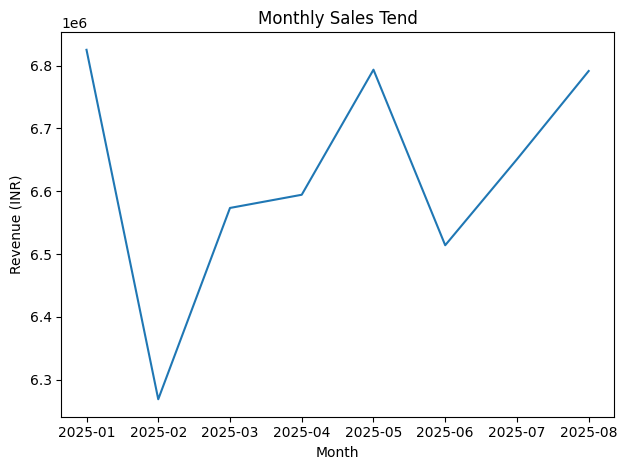

In [14]:
#chart Design

#Monthly Sales trend

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

Monthly_revenue = df.groupby("YearMonth")['Price (INR)'].sum().reset_index()


plt.figure()
plt.plot(Monthly_revenue["YearMonth"],Monthly_revenue["Price (INR)"])
#plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Sales Tend")
plt.tight_layout()
plt.show()


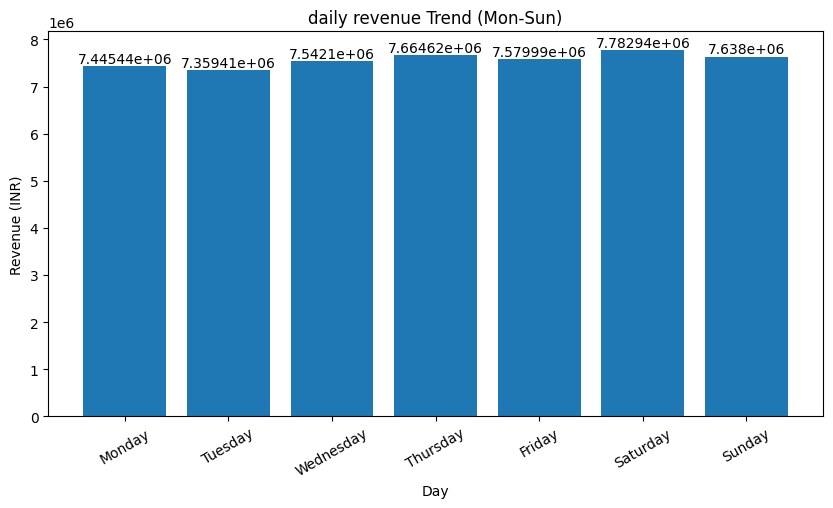

In [27]:
#Daily Sales Trend

df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()
daily_revenue = df.groupby("DayName")['Price (INR)'].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])


plt.figure(figsize=(10,5))
bars=plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("daily revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation = 30)
plt.bar_label(bars)


plt.show()

In [31]:
#Total Sales by Food Type(Veg vs Non-Veg)
non_veg_keywords = ["chicken","egg","fish","mutton","ArithmeticError"
"beef","prawn","biryani","kabab","meat","non_veg"]

df["Food category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords),na=False),
    "Non_veg",
    "Veg"
)



food_revenue = df.groupby("Food category")['Price (INR)'].sum().reset_index()

In [37]:
fig = px.pie(
    food_revenue,
    values ="Price (INR)",
    names = "Food category",
    hole = 0.5,
    title = "Revenue Contribution :veg vs Non-veg"

)

fig.update_traces(
    textinfo = "label+percent",
    pull=[0.05,0]
)

fig.update_layout(
    height = 400,
    margin = dict(t=60,b=40,l=40,r=40)
)

fig.show()

In [44]:
#Total Rvenue by state

total_revenue_by_state = df.groupby("State")['Price (INR)'].sum().reset_index().sort_values(by = 'Price (INR)',ascending = False)
total_revenue_by_state

fig = px.bar(
    total_revenue_by_state,
    x = "Price (INR)",
    y = "State",
    orientation ="h",
    title = "Revenue by State"
)

fig.update_layout(height = 400,yaxis =dict(autorange ="reversed"))
fig.show()




In [45]:
#Quaterly Performance Summary

df["Order_Date"] = pd.to_datetime(df["Order Date"])

df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index=False)
      .agg(
          Total_Sales=("Price (INR)", "sum"),
          Avg_Rating=("Rating", "mean"),
          Total_Orders=("Order_Date", "count")
      )
      .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary
                   

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


In [46]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
      .sum()
      .nlargest(5)
      .sort_values()
      .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()